#### 1. Set up the reaction graph from DFT data 

In [1]:
from arcs.generate import GraphGenerator

graph = GraphGenerator().from_file(
    filename='../src/arcs/data/dft_data.json',
    temperature=248,
    pressure=20,
    max_reaction_length=5,
    log_K = True
)

In [2]:
graph.nodes[0]

{'reaction': {'reaction_string': '2 CH2O2 = 1 O2 + 1 CH3COOH',
  'reactants': {'CH2O2': 2},
  'products': {'O2': 1, 'CH3COOH': 1}},
 'log_equilibrium_constant': -162.34309469988966}

#### 2. Sample the `graph`

In [ ]:
from arcs.traversal import Traversal
from arcs.generate import GenerateInitialConcentrations

gic = GenerateInitialConcentrations(graph=graph).update_ic(
    {'H2O':30,'O2':10,'SO2':10,'H2S':0,'NO2':10,"CH4":2.95}
    )

t = Traversal(graph=graph)

data = t.sample(initial_concentrations=gic,ncpus=4,nsamples=1000,**{"use_chempy":False})

  0%|          | 0/1000 [00:00<?, ?it/s]

#### 3. generate reaction statistics

In [17]:
from arcs.analysis import AnalyseSampling
import pandas as pd 

analysis = AnalyseSampling()
stats = pd.Series(analysis.reaction_statistics(data)).sort_values(ascending=False)
stats.head(20)

2 CH4 + 4 H2O + 1 S8 = 2 CO2 + 8 H2S        349
2 H2 + 1 O2 = 2 H2O                         327
1 H2SO3 = 1 H2O + 1 SO2                     277
2 O2 + 4 CH4 + 1 S8 = 4 CO + 8 H2S          198
1 O2 + 1 H2CO + 1 SO2 = 1 CO2 + 1 H2SO3     182
4 O2 + 4 CH4 + 1 S8 = 4 CO2 + 8 H2S         178
2 O2 + 1 CH4 + 1 SO2 = 1 CH2O2 + 1 H2SO4    167
1 CH3OH + 1 SO2 = 1 CO2 + 1 H2O + 1 H2S     164
1 CH2O2 + 1 O2 + 1 SO2 = 1 CO2 + 1 H2SO4    156
3 H2 + 1 SO2 = 2 H2O + 1 H2S                151
1 O2 + 1 H2CO + 1 SO2 = 1 CO + 1 H2SO4      139
2 O2 + 1 CH4 = 1 CO2 + 2 H2O                136
1 CO + 1 O2 + 1 H2S = 1 H2CO + 1 SO2        127
1 H2 + 1 O2 + 1 SO2 = 1 H2SO4               124
1 H2 + 1 H2SO4 = 2 H2O + 1 SO2              120
1 CH2O2 + 1 H2S = 1 CH4 + 1 SO2             117
8 O2 + 1 S8 = 8 SO2                         115
1 O2 + 1 H2CO = 1 CO2 + 1 H2O                95
1 O2 + 1 H2S = 1 H2 + 1 SO2                  94
1 O2 + 1 CH4 = 1 CH2O2 + 1 H2                91
dtype: int64

#### 4. generate mean concentrations and differences

In [18]:
average_data = pd.DataFrame(analysis.average_sampling(data))
average_data = average_data.loc[~(average_data==0).all(axis=1)]
average_data.sort_values(by='diff',inplace=True)
print(average_data.round(2).to_string())

          initial   mean  diff   sem   std    var
O2           10.0   6.38 -3.62  0.07  4.70  22.10
CH4          10.0   7.30 -2.70  0.06  3.89  15.17
SO2          10.0   9.07 -0.93  0.03  2.43   5.91
S8            0.0  -0.00 -0.00  0.00  0.02   0.00
CH3OH         0.0  -0.00 -0.00  0.00  0.00   0.00
CH3CHO        0.0   0.00  0.00  0.00  0.00   0.00
CO            0.0   0.03  0.03  0.01  0.46   0.21
H2S           0.0   0.05  0.05  0.00  0.35   0.12
CH3CH2OH      0.0   0.08  0.08  0.01  0.63   0.40
CH3COOH       0.0   0.10  0.10  0.01  0.68   0.47
H2SO3         0.0   0.14  0.14  0.02  1.15   1.32
H2CO          0.0   0.47  0.47  0.03  2.11   4.45
H2SO4         0.0   0.74  0.74  0.03  2.16   4.66
CO2           0.0   0.80  0.80  0.03  2.25   5.08
CH2O2         0.0   1.05  1.05  0.04  2.68   7.20
H2O          30.0  31.25  1.25  0.06  4.07  16.57
H2            0.0   1.27  1.27  0.06  4.16  17.32


#### 5. Plot 

/var/folders/40/xmstzxyn7377k__pn0yxn6w80000gn/T/ipykernel_3916/949321809.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(name='RdBu')  # or any other colormap


<Axes: >

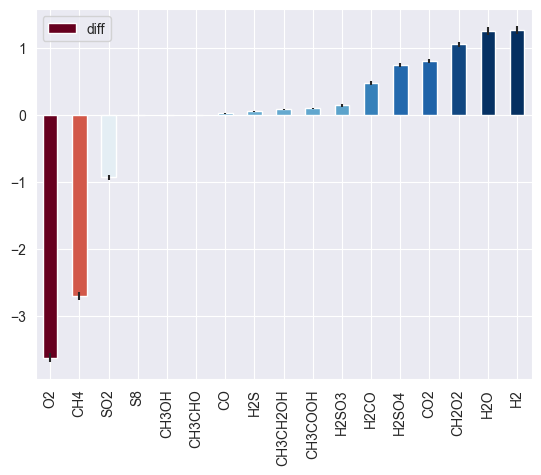

In [19]:
import seaborn as sns 
from matplotlib.cm import get_cmap
import matplotlib.colors as colors
sns.set_style('darkgrid')
sns.set_palette('pastel')


norm = colors.Normalize(
    vmin=average_data['diff'].min(), vmax=average_data['diff'].max()
    )
cmap = get_cmap(name='RdBu')  # or any other colormap

bar_colors = [cmap(norm(value)) for value in average_data['diff']]

average_data.plot.bar(y='diff',yerr='sem',color=bar_colors)

#### 5. generate a `pyvis` graph 

In [ ]:
pyvis_kwargs = {'width':'50%','notebook':False,"font_color":'white','directed':True}
g = analysis.result_to_pyvis(data,head=10,**pyvis_kwargs)
g.save_graph(name="example_pyvis_graph.html")

In [ ]:
! open example_pyvis_graph.html